# 📈 Forecasting Analysis — Age-Cohort Shift Projection

---

## Tujuan
Mengevaluasi proyeksi demand siswa SD dan SMP di 31 kecamatan Kota Surabaya untuk
tahun 2025–2030 menggunakan model **Cohort Survival Method**, serta menghitung akurasi
model menggunakan **MAPE** (*Mean Absolute Percentage Error*).

---

## Model: Cohort Survival Method

Model ini menggunakan data populasi usia per kecamatan sebagai basis proyeksi:

$$\text{Demand}_{Y, i} = \sum_{a \in \text{usia}(Y)} P_{a-(Y-2025), i}$$

Dimana:
- $Y$ = tahun proyeksi (2025–2030)
- $i$ = kecamatan
- $P_{a, i}$ = jumlah penduduk usia $a$ di kecamatan $i$ (data 2025)
- Usia SD: 7–12 tahun | Usia SMP: 13–15 tahun

Asumsi: cohort yang sekarang berusia $a$ akan berusia $a+1$ tahun depan (zero-migration).

In [1]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
                "pandas", "numpy", "matplotlib", "seaborn", "scikit-learn"])


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


CompletedProcess(args=['/Users/nimahfauziyyah/4smt-2026/matkul/bigdata/ETS-BD-5-A/.venv/bin/python', '-m', 'pip', 'install', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn'], returncode=0)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='tab10', font='DejaVu Sans')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})
DATA = '../medallion/exports/'      # path CSV dari 08_analysis2.py
print('Libraries loaded OK')

Libraries loaded OK


In [3]:
# ── Load data ───────────────────────────────────────────────────────────────
demand = pd.read_csv(DATA + 'demand_proyeksi.csv')
print(f'Baris: {len(demand):,}  |  Kolom: {list(demand.columns)}')
demand.head(6)

Baris: 186  |  Kolom: ['kecamatan_key', 'kecamatan_norm', 'tahun_proyeksi', 'demand_sd', 'demand_smp', 'demand_total']


,kecamatan_key,kecamatan_norm,tahun_proyeksi,demand_sd,demand_smp,demand_total
0,GENTENG,GENTENG,2030,4599,2518,7117
1,SAWAHAN,SAWAHAN,2030,15984,8796,24780
2,SUKOMANUNGGAL,SUKOMANUNGGAL,2030,8884,4871,13755
3,ASEMROWO,ASEMROWO,2030,5134,2565,7699
4,WONOKROMO,WONOKROMO,2030,12014,6602,18616
5,PABEANCANTIAN,PABEAN CANTIAN,2030,6659,3480,10139


## 1. Total Demand Surabaya 2025–2030

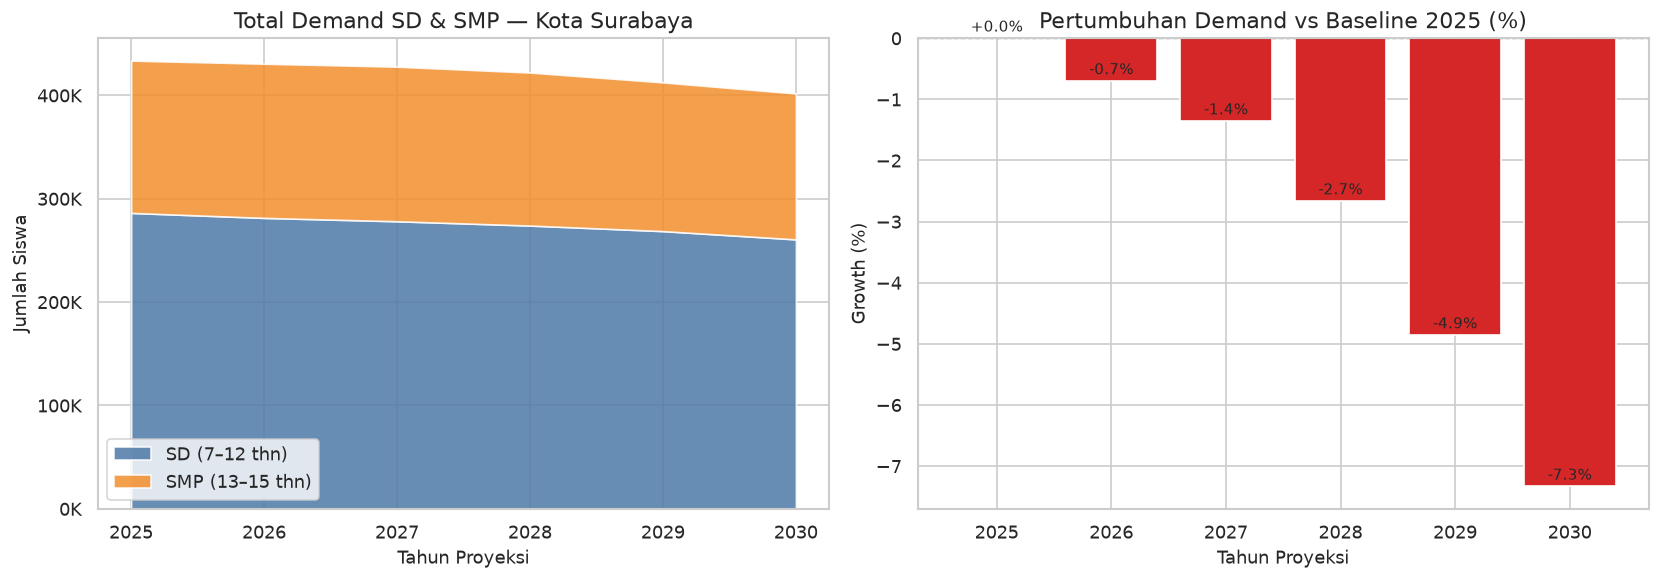

,tahun_proyeksi,demand_sd,demand_smp,demand_total,growth_pct
0,2025,286240,147342,433582,0.000000
1,2026,281411,149146,430557,-0.697677
2,2027,278152,149558,427710,-1.354300
3,2028,273999,148039,422038,-2.662472
4,2029,268626,143901,412527,-4.856060
5,2030,260622,141167,401789,-7.332638


In [4]:
city = demand.groupby('tahun_proyeksi')[['demand_sd','demand_smp','demand_total']].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked area — SD vs SMP
ax = axes[0]
ax.stackplot(city['tahun_proyeksi'], city['demand_sd'], city['demand_smp'],
             labels=['SD (7–12 thn)', 'SMP (13–15 thn)'],
             colors=['#4E79A7','#F28E2B'], alpha=0.85)
ax.set_title('Total Demand SD & SMP — Kota Surabaya')
ax.set_xlabel('Tahun Proyeksi')
ax.set_ylabel('Jumlah Siswa')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.legend(loc='lower left')

# Growth bar
ax2 = axes[1]
base = city.loc[city['tahun_proyeksi']==2025,'demand_total'].values[0]
city['growth_pct'] = (city['demand_total'] - base) / base * 100
bars = ax2.bar(city['tahun_proyeksi'], city['growth_pct'],
               color=['#76b900' if v>=0 else '#d62728' for v in city['growth_pct']])
ax2.axhline(0, color='grey', lw=0.8, ls='--')
ax2.set_title('Pertumbuhan Demand vs Baseline 2025 (%)')
ax2.set_xlabel('Tahun Proyeksi')
ax2.set_ylabel('Growth (%)')
for bar, val in zip(bars, city['growth_pct']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
             f'{val:+.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
city

## 2. Proyeksi Per Kecamatan (Heatmap)

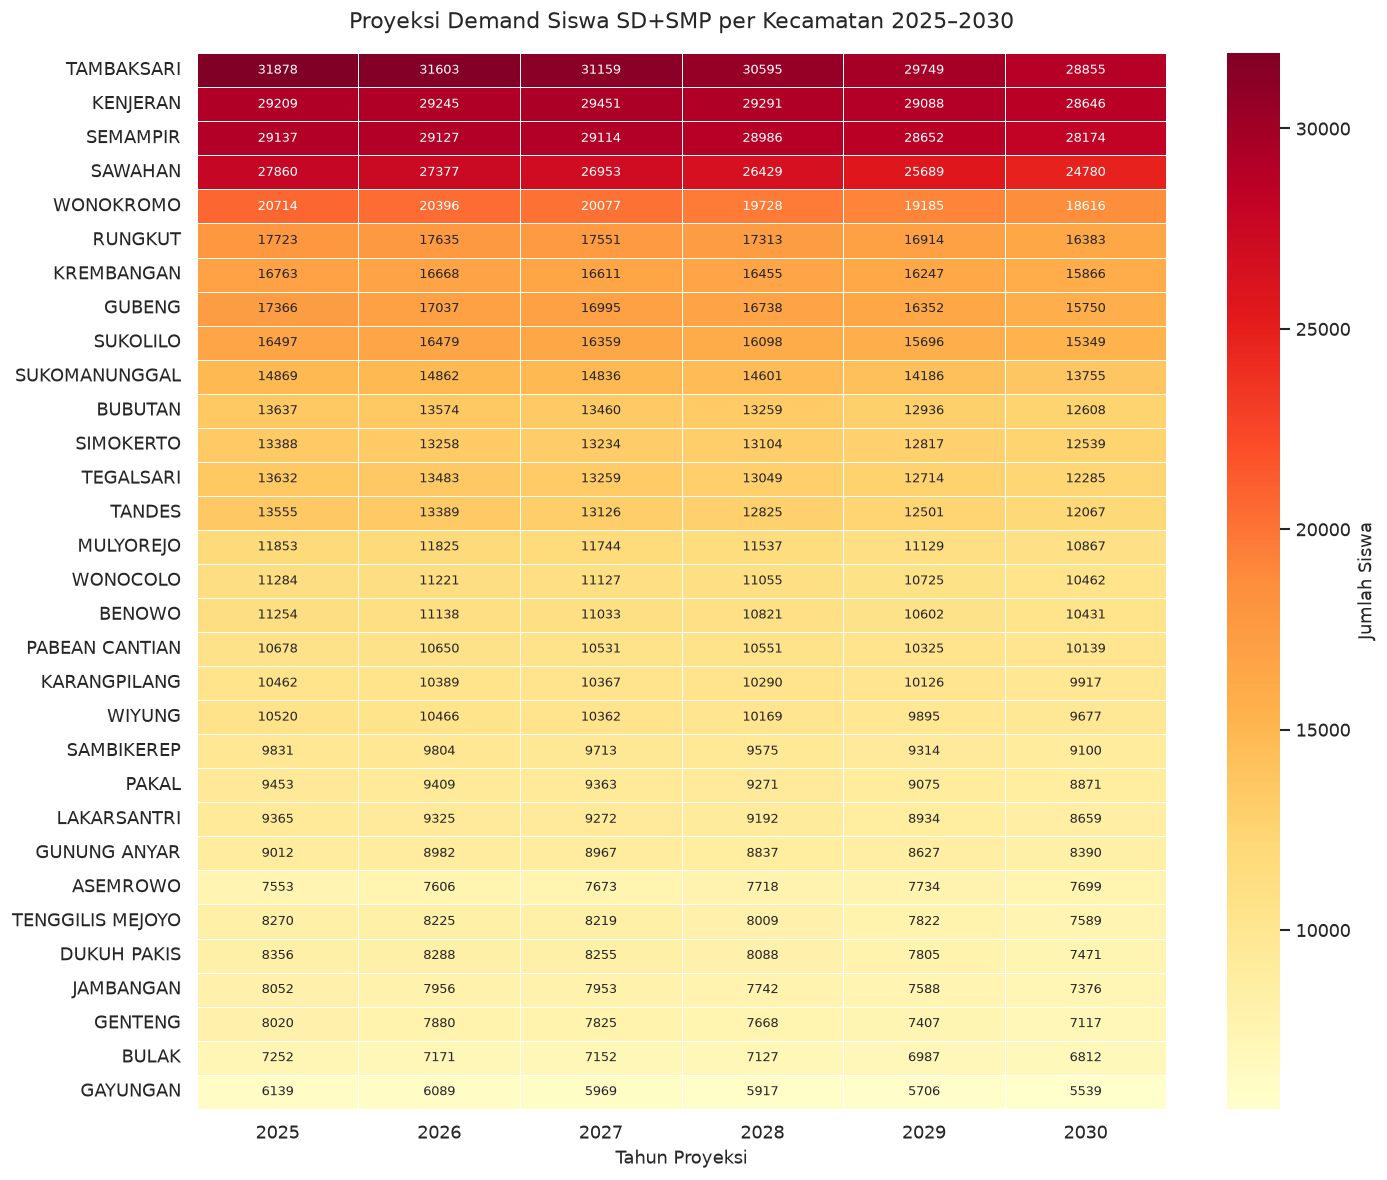

In [5]:
pivot = demand.pivot_table(index='kecamatan_norm', columns='tahun_proyeksi',
                            values='demand_total', aggfunc='sum')
pivot = pivot.sort_values(2030, ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.4, ax=ax, annot_kws={'size': 8},
            cbar_kws={'label': 'Jumlah Siswa'})
ax.set_title('Proyeksi Demand Siswa SD+SMP per Kecamatan 2025–2030', pad=15)
ax.set_ylabel('')
ax.set_xlabel('Tahun Proyeksi')
plt.tight_layout()
plt.show()

## 3. Top-10 Kecamatan — Demand 2030

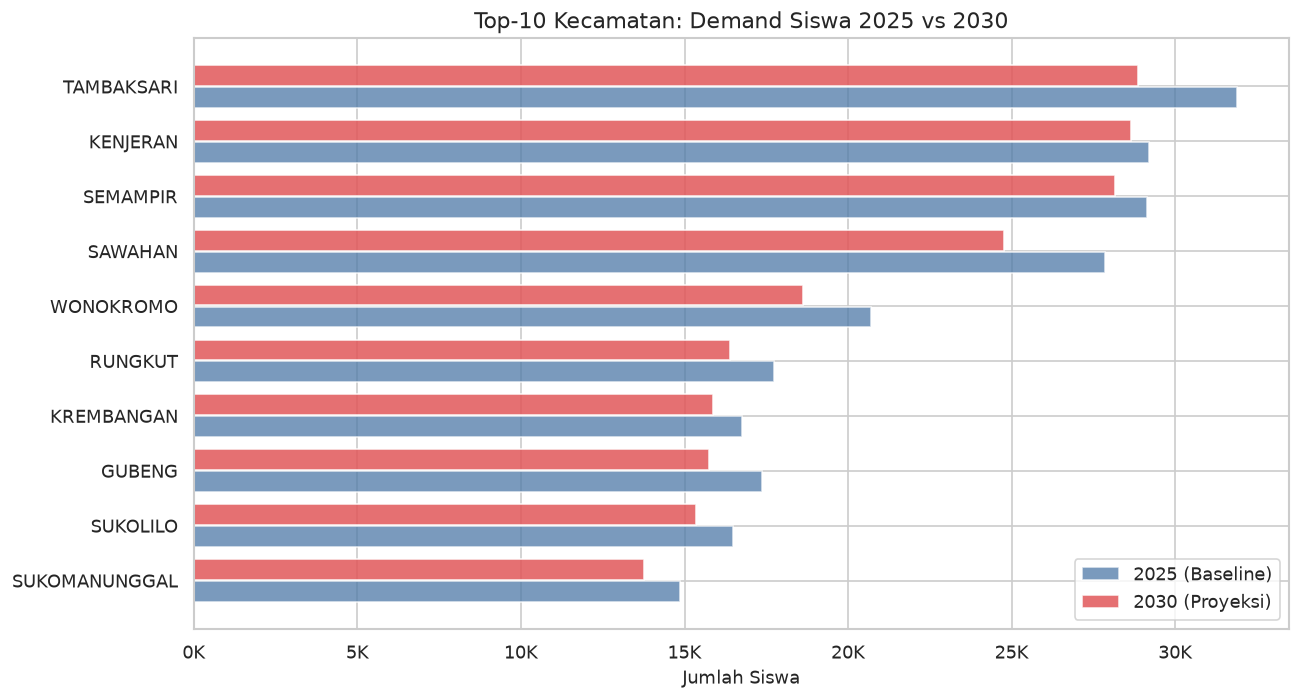

In [6]:
d2030 = demand[demand['tahun_proyeksi']==2030].sort_values('demand_total', ascending=False).head(10)
d2025 = demand[demand['tahun_proyeksi']==2025].set_index('kecamatan_norm')['demand_total']

fig, ax = plt.subplots(figsize=(11, 6))
y = np.arange(len(d2030))
kec = d2030['kecamatan_norm'].values

bars_2025 = ax.barh(y + 0.2, d2025.reindex(kec).values, 0.38, label='2025 (Baseline)',
                    color='#4E79A7', alpha=0.75)
bars_2030 = ax.barh(y - 0.2, d2030['demand_total'].values, 0.38, label='2030 (Proyeksi)',
                    color='#E15759', alpha=0.85)

ax.set_yticks(y)
ax.set_yticklabels(kec)
ax.set_xlabel('Jumlah Siswa')
ax.set_title('Top-10 Kecamatan: Demand Siswa 2025 vs 2030')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. MAPE Evaluation — Akurasi Model Cohort


  Overall MAPE = 42.23%
  Status       = PERLU PERBAIKAN (≥ 30%)



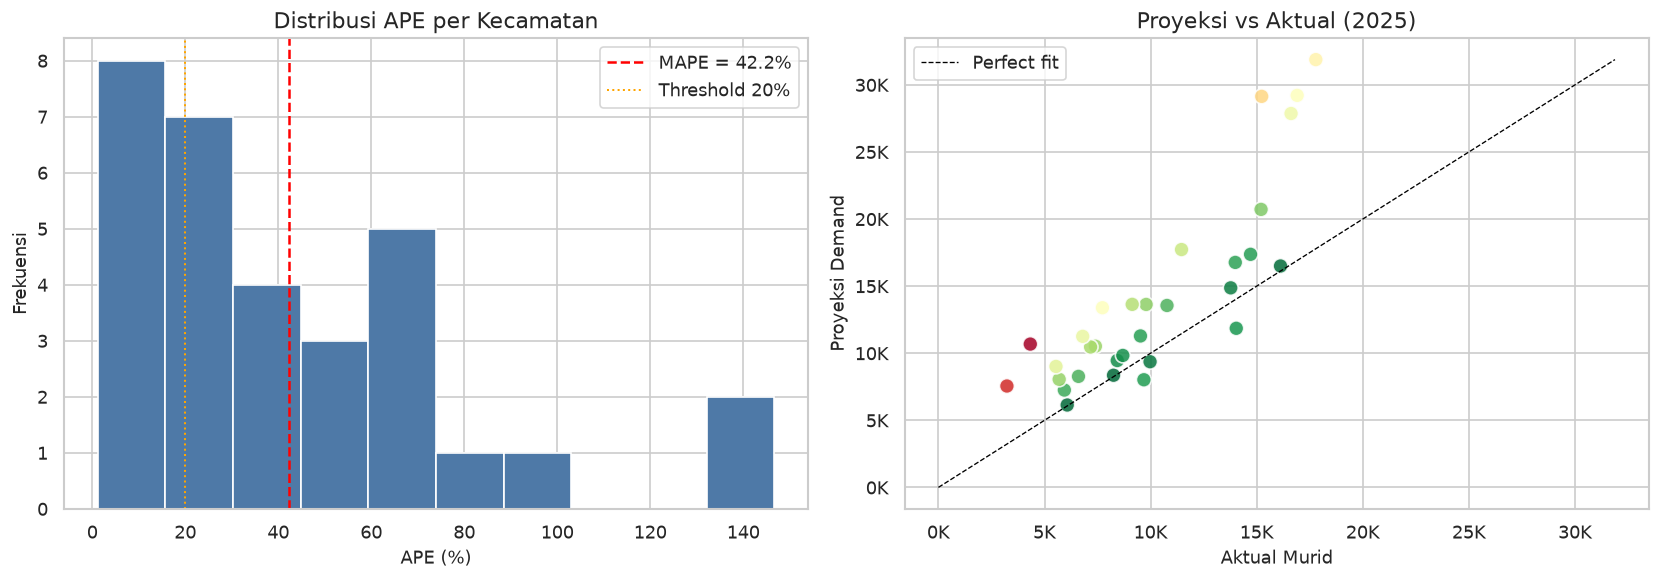

,kecamatan_key,projected_murid,actual_murid,ape
5,GAYUNGAN,6139.0,6068.0,1.170073
4,DUKUHPAKIS,8356.0,8250.0,1.284848
22,SUKOLILO,16497.0,16119.0,2.345059
13,LAKARSANTRI,9365.0,9972.0,6.087044
23,SUKOMANUNGGAL,14869.0,13772.0,7.965437
16,PAKAL,9453.0,8427.0,12.175151
18,SAMBIKEREP,9831.0,8688.0,13.156077
14,MULYOREJO,11853.0,14034.0,15.540829
6,GENTENG,8020.0,9681.0,17.157318
7,GUBENG,17366.0,14707.0,18.079826


In [7]:
mape_detail = pd.read_csv(DATA + 'mape_detail.csv')
mape_detail = mape_detail.sort_values('ape')
overall_mape = mape_detail['ape'].mean()

print(f'\n{'='*50}')
print(f'  Overall MAPE = {overall_mape:.2f}%')
quality = ('BAIK (< 20%)' if overall_mape < 20
           else 'CUKUP (< 30%)' if overall_mape < 30
           else 'PERLU PERBAIKAN (≥ 30%)')
print(f'  Status       = {quality}')
print(f'{'='*50}\n')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# APE distribution
axes[0].hist(mape_detail['ape'], bins=10, color='#4E79A7', edgecolor='white')
axes[0].axvline(overall_mape, color='red', ls='--', lw=1.5, label=f'MAPE = {overall_mape:.1f}%')
axes[0].axvline(20, color='orange', ls=':', lw=1.2, label='Threshold 20%')
axes[0].set_title('Distribusi APE per Kecamatan')
axes[0].set_xlabel('APE (%)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Projected vs Actual scatter
ax2 = axes[1]
ax2.scatter(mape_detail['actual_murid'], mape_detail['projected_murid'],
            c=mape_detail['ape'], cmap='RdYlGn_r', s=80, alpha=0.85, edgecolors='white')
lim = max(mape_detail[['actual_murid','projected_murid']].max())
ax2.plot([0,lim],[0,lim], 'k--', lw=0.8, label='Perfect fit')
ax2.set_title('Proyeksi vs Aktual (2025)')
ax2.set_xlabel('Aktual Murid')
ax2.set_ylabel('Proyeksi Demand')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax2.legend()

plt.tight_layout()
plt.show()
mape_detail

---
## 📌 Kesimpulan

| Item | Nilai |
|------|-------|
| Model | Cohort Survival Method |
| Horizon Proyeksi | 2025–2030 |
| Jumlah Kecamatan | 31 |
| Overall MAPE | lihat output sel di atas |

**Interpretasi MAPE:**
- < 20% → Model **akurat**, bisa digunakan untuk perencanaan
- 20–30% → Model **cukup**, gunakan dengan hati-hati
- ≥ 30% → Model perlu kalibrasi (tambah data migrasi / angka partisipasi sekolah)